<a href="https://colab.research.google.com/github/joelarisee/-Deep-Learning-Based-Object-Detection-in-Video-and-Video-Processing-Analysis/blob/master/minipro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rasterio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 43.3 MB/s eta 0:00:00


In [ ]:
import os
import rasterio
import numpy as np
import cv2


from skimage.filters import threshold_otsu
from scipy.stats import ttest_rel

from google.colab import files
from google.colab.patches import cv2_imshow  # Required for image display in Colab

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter
from skimage.filters import threshold_otsu
from scipy.stats import ttest_rel

In [ ]:
# Initialize feature and label storage
all_features = []
all_labels = []


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving msg.TIF to msg.TIF
Saving msnir.TIF to msnir.TIF
Saving msr.TIF to msr.TIF
Saving msre.TIF to msre.TIF


In [ ]:
with rasterio.open('msnir.TIF') as nir_src:
    nir_band = nir_src.read(1).astype(np.float32) / 255.0

with rasterio.open('msr.TIF') as red_src:
    red_band = red_src.read(1).astype(np.float32) / 255.0

with rasterio.open('msg.TIF') as green_src:
    green_band = green_src.read(1).astype(np.float32) / 255.0

with rasterio.open('msre.TIF') as blue_src:
    blue_band = blue_src.read(1).astype(np.float32) / 255.0

# Compute vegetation indices
NDVI = (nir_band - red_band) / (nir_band + red_band + 1e-5)
GNDVI = (nir_band - green_band) / (nir_band + green_band + 1e-5)
EVI = 2.5 * (nir_band - red_band) / (nir_band + 6 * red_band - 7.5 * blue_band + 1e-5)
MSAVI = (2 * nir_band + 1 - np.sqrt((2 * nir_band + 1) ** 2 - 8 * (nir_band - red_band))) / 2

HVI = 0.40 * NDVI + 0.30 * GNDVI + 0.20 * EVI + 0.10 * MSAVI
HVI = median_filter(HVI, size=3)

# Thresholding with Otsu
threshold = threshold_otsu(HVI)
segmented_mask = HVI > threshold

# Extract valid pixel features
valid_mask = segmented_mask.flatten()
features = np.column_stack([
    NDVI.flatten(),
    GNDVI.flatten(),
    EVI.flatten(),
    MSAVI.flatten(),
    HVI.flatten()])
features = features[valid_mask]
labels = np.zeros(features.shape[0], dtype=int)

# Class 0: Highly healthy (strong in both NDVI and GNDVI)
labels[(features[:, 0] > 0.6) & (features[:, 1] > 0.5)] = 0

# Class 1: Mild stress or rust (NDVI moderate, GNDVI low)
labels[(features[:, 0] > 0.3) & (features[:, 0] <= 0.6) & (features[:, 1] <= 0.5)] = 1

# Class 2: Severe stress or poor vegetation
labels[features[:, 0] <= 0.3] = 2
all_features.append(features)
all_labels.append(labels)
all_features = np.vstack(all_features)
all_labels= np.concatenate(all_labels)


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


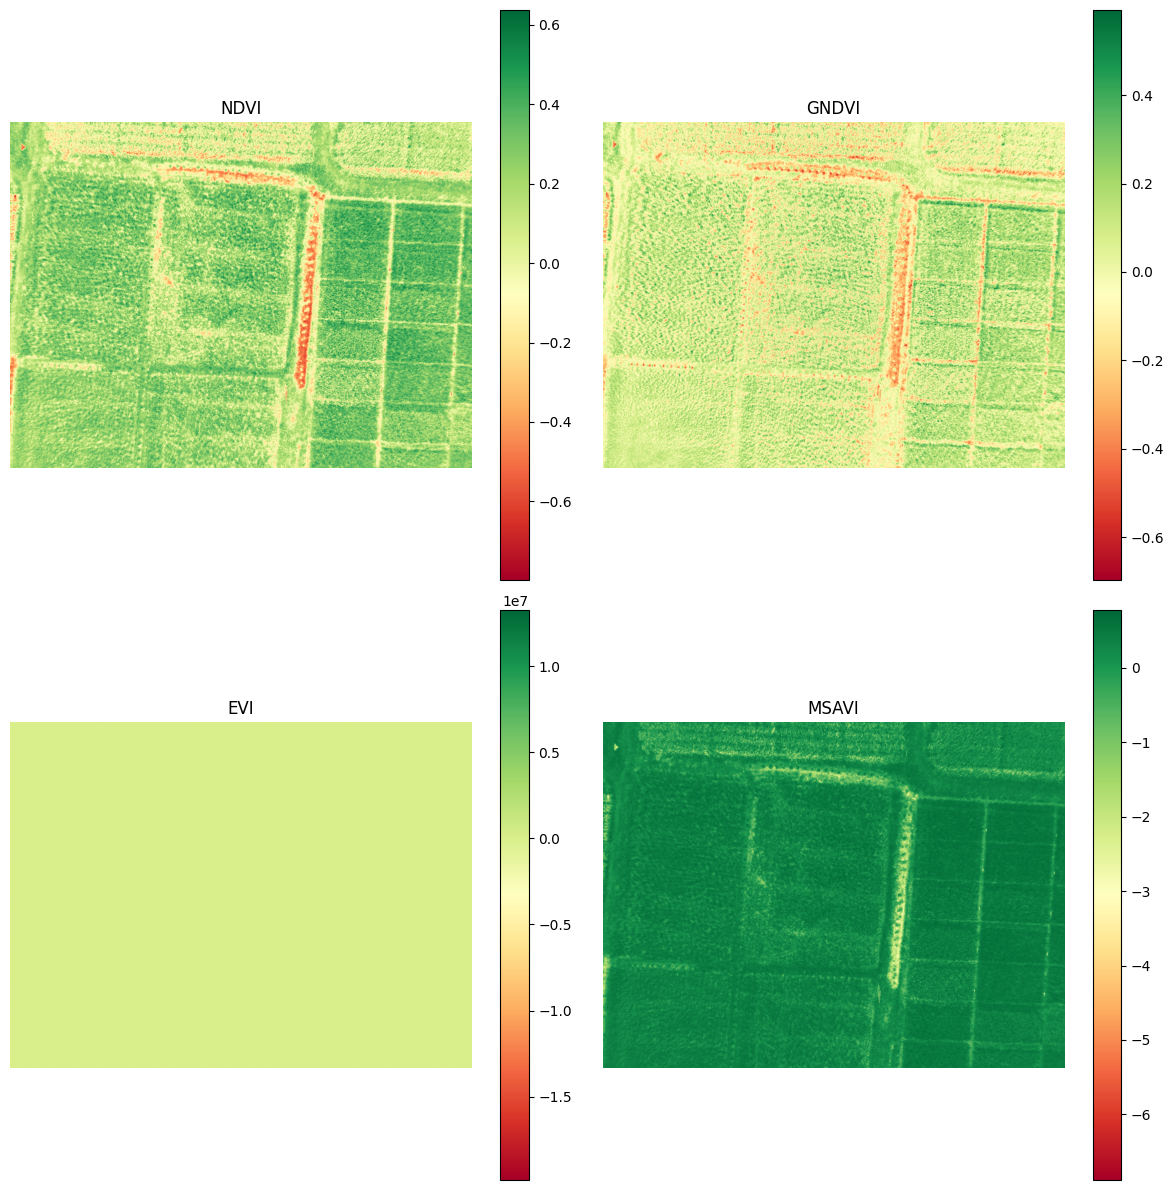

In [ ]:
import matplotlib.pyplot as plt
# Create a 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Plot NDVI
im1 = axes[0, 0].imshow(NDVI, cmap='RdYlGn')
axes[0, 0].set_title('NDVI')
axes[0, 0].axis('off')
fig.colorbar(im1, ax=axes[0, 0])

# Plot GNDVI
im2 = axes[0, 1].imshow(GNDVI, cmap='RdYlGn')
axes[0, 1].set_title('GNDVI')
axes[0, 1].axis('off')
fig.colorbar(im2, ax=axes[0, 1])

# Plot EVI
im3 = axes[1, 0].imshow(EVI, cmap='RdYlGn')
axes[1, 0].set_title('EVI')
axes[1, 0].axis('off')
fig.colorbar(im3, ax=axes[1, 0])

# Plot MSAVI
im4 = axes[1, 1].imshow(MSAVI, cmap='RdYlGn')
axes[1, 1].set_title('MSAVI')
axes[1, 1].axis('off')
fig.colorbar(im4, ax=axes[1, 1])

# Display all
plt.tight_layout()
plt.show()


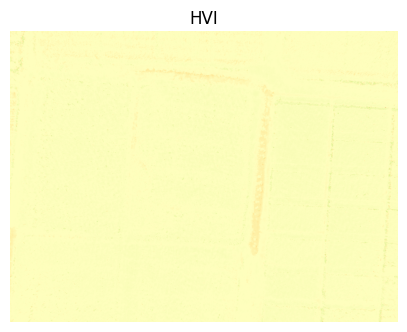

In [ ]:

plt.figure(figsize=(5, 5))
plt.imshow(HVI, cmap='RdYlGn')
plt.title('HVI')
plt.axis('off')  # Turn off the axis for better visualization
plt.show()

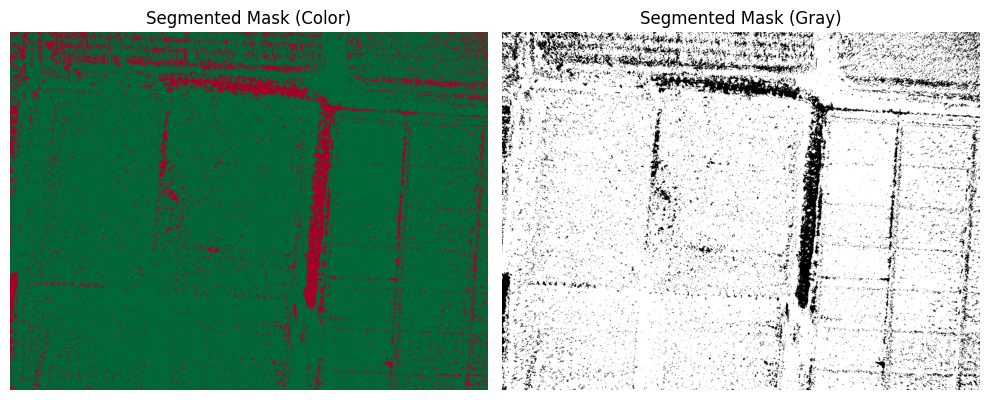

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(segmented_mask, cmap='RdYlGn')
axes[0].set_title('Segmented Mask (Color)')
axes[0].axis('off')

axes[1].imshow(segmented_mask, cmap='gray')
axes[1].set_title('Segmented Mask (Gray)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
x_train, x_val, y_train, y_val = train_test_split(
    all_features, all_labels, test_size=0.2, random_state=42
)


In [ ]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define Fully Connected Neural Network (FCNN) model
model = Sequential([
    Input(shape=(5,)),  # 5 vegetation index features (NDVI, GNDVI, EVI, MSAVI, HVI)
    Dense(64, activation='relu'),
    Dropout(0.3),  # Helps prevent overfitting
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # 3 output classes
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/MiniProject/bestmodel.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/100
55928/55943 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9777 - loss: 5.2254
Epoch 1: val_accuracy improved from -inf to 0.99448, saving model to /content/drive/MyDrive/MiniProject/bestmodel.keras
55943/55943 ━━━━━━━━━━━━━━━━━━━━ 168s 3ms/step - accuracy: 0.9777 - loss: 5.2254 - val_accuracy: 0.9945 - val_loss: 0.9457
Epoch 2/100
55924/55943 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9917 - loss: 3.0955
Epoch 2: val_accuracy improved from 0.99448 to 0.99708, saving model to /content/drive/MyDrive/MiniProject/bestmodel.keras
55943/55943 ━━━━━━━━━━━━━━━━━━━━ 182s 3ms/step - accuracy: 0.9917 - loss: 3.0955 - val_accuracy: 0.9971 - val_loss: 2.6195
Epoch 3/100
55931/55943 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9928 - loss: 1.8176
Epoch 3: val_accuracy did not improve from 0.99708
55943/55943 ━━━━━━━━━━━━━━━━━━━━ 203s 3ms/step - accuracy: 0.9928 - loss: 1.8175 - val_accuracy: 0.9953 - val_loss: 0.0874
Epoch 4/100
55935/55943 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accur

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import joblib
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
joblib.dump(model, '/content/drive/MyDrive/MiniProject/logistic_regression_model.joblib')
y_pred = model.predict(x_val)
accuracy = accuracy_score(y_val, y_pred)
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

Logistic Regression Model Accuracy: 0.9991


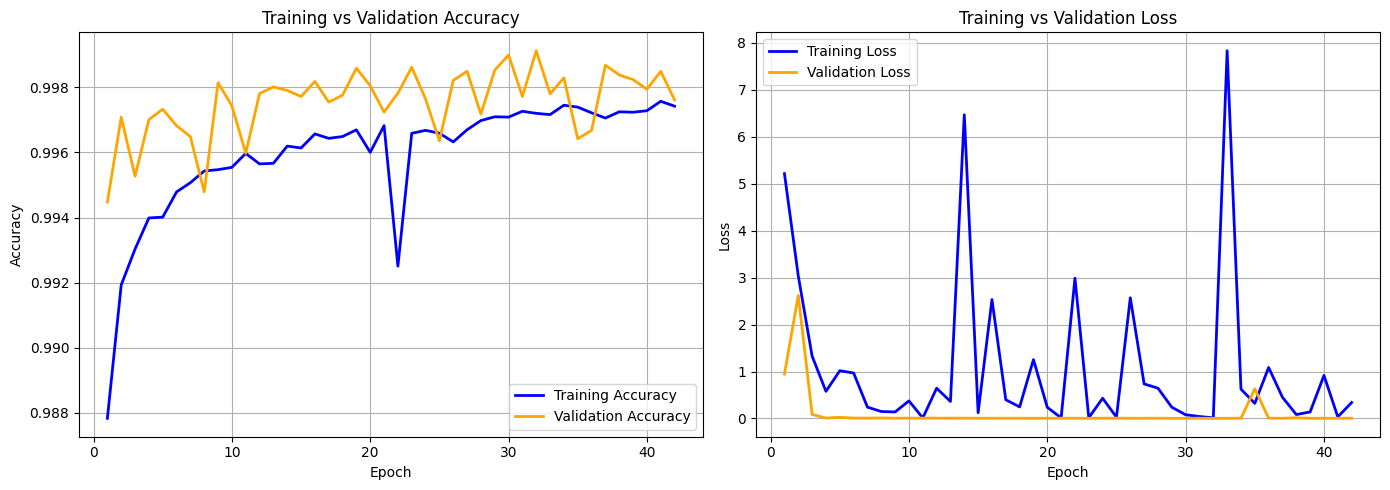

In [ ]:
import matplotlib.pyplot as plt

# Extract values
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Set the figure size
plt.figure(figsize=(14, 5))

# 📈 Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 📉 Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Display
plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.models import load_model
model=load_model('/content/drive/MyDrive/MiniProject/bestmodel.keras')

In [ ]:
final_loss, final_accuracy = model.evaluate(x_val, y_val)
print(f"Final Loss: {final_loss:.4f}, Final Accuracy: {final_accuracy:.4f}")


27972/27972 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step - accuracy: 0.9992 - loss: 0.0027
Final Loss: 0.0028, Final Accuracy: 0.9991


In [ ]:
# Testing Phase
# -------------------------

# Normalize bands
RED_test = red_band[100:200, 100:200].astype(np.float32) / 255.0
GREEN_test = green_band[100:200, 100:200].astype(np.float32) / 255.0
BLUE_test = blue_band[100:200, 100:200].astype(np.float32) / 255.0
NIR_test = nir_band[100:200, 100:200].astype(np.float32) / 255.0

# -------------------------
# Compute vegetation indices
# -------------------------
NDVI_test = (NIR_test - RED_test) / (NIR_test + RED_test + 1e-8)
GNDVI_test = (NIR_test - GREEN_test) / (NIR_test + GREEN_test + 1e-8)
EVI_test = 2.5 * (NIR_test - RED_test) / (NIR_test +6* RED_test - 7.5 * BLUE_test + 1 + 1e-8)
MSAVI_test = (2 * NIR_test + 1 - np.sqrt((2 * NIR_test + 1) ** 2 - 8 * (NIR_test - RED_test))) / 2
HVI_test = 0.25 * (NDVI_test + GNDVI_test + EVI_test + MSAVI_test)

# -------------------------
# Preprocessing and segmentation
# -------------------------
HVI_test = median_filter(HVI_test, size=3)
threshold = threshold_otsu(HVI_test)
segmentedMask_test = HVI_test > threshold

# -------------------------
# Extract features
# -------------------------
validMask_test = segmentedMask_test.flatten()
testFeatures = np.stack([
    NDVI_test.flatten(),
    GNDVI_test.flatten(),
    EVI_test.flatten(),
    MSAVI_test.flatten(),
    HVI_test.flatten()
], axis=1)

testFeatures = testFeatures[validMask_test]

# Predict
predictions = model.predict(testFeatures)
predicted_classes = np.argmax(predictions, axis=1)
print("Predicted class distribution:", np.bincount(predicted_classes))


143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted class distribution: [   0    0 4575]


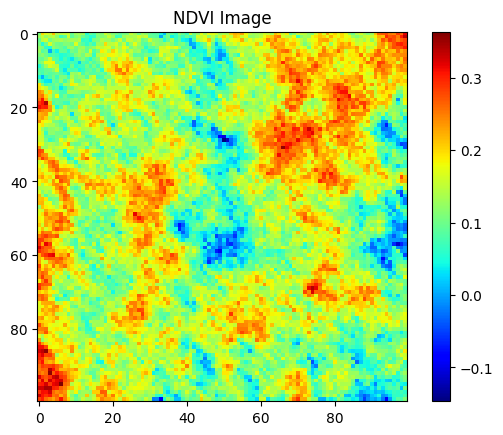

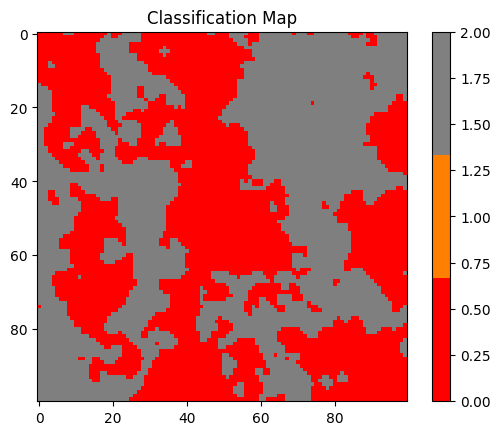

In [ ]:

# Display results
# -------------------------
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(NDVI_test, cmap='jet')
plt.colorbar()
plt.title('NDVI Image')
plt.show()

# Optional: Show segmented mask
# plt.figure()
# plt.imshow(segmentedMask_test, cmap='gray')
# plt.title('Preprocessed Segmentation')
# plt.show()

# -------------------------
# Generate classification map
# -------------------------
classificationMap_test = np.zeros(segmentedMask_test.shape, dtype=np.uint8)
classificationMap_test[segmentedMask_test] = predicted_classes

plt.figure()
cmap = plt.cm.colors.ListedColormap([(1, 0, 0), (1, 0.5, 0), (0.5, 0.5, 0.5)])  # Red, Orange, Gray
plt.imshow(classificationMap_test, cmap=cmap)
plt.colorbar()
plt.title('Classification Map')
plt.show()
